In [7]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set(style="whitegrid")

# 1. Load the count sheets from Supplementary_Data_1.xlsx
file_path = "../data/raw/Supplementary_Data_1.xlsx"

# adjust sheet_name indices once you verify which is RNA and which is DNA
rna_counts = pd.read_excel(file_path, sheet_name=4)
dna_counts = pd.read_excel(file_path, sheet_name=5)

rna_counts.head()
dna_counts.head()


,ID,6335-13999,7816-14807,8471-13449,Sum
0,UCI_10,0,0,6,9
1,UCI_11,26,0,36,82
2,UCI_12,0,12,0,12
3,UCI_13,0,0,23,23
4,UCI_14,0,0,13,15


In [2]:
del_cols = ['6335-13999', '7816-14807', '8471-13449']

for col in del_cols:
    rna_counts[col + '_pct'] = rna_counts[col] / rna_counts['Sum'] * 100
    dna_counts[col + '_pct'] = dna_counts[col] / dna_counts['Sum'] * 100

rna_pct = rna_counts[['ID'] + [c + '_pct' for c in del_cols]]
dna_pct = dna_counts[['ID'] + [c + '_pct' for c in del_cols]]

merged = rna_pct.merge(dna_pct, on='ID', suffixes=('_rna', '_dna'))
merged.head()



,ID,6335-13999_pct_rna,7816-14807_pct_rna,8471-13449_pct_rna,6335-13999_pct_dna,7816-14807_pct_dna,8471-13449_pct_dna
0,UCI_10,20.762712,12.711864,7.627119,0.000000,0.0,66.666667
1,UCI_11,12.057272,6.932931,12.283346,31.707317,0.0,43.902439
2,UCI_12,2.250352,2.953586,1.969058,0.000000,100.0,0.000000
3,UCI_13,27.397260,4.109589,9.589041,0.000000,0.0,100.000000
4,UCI_14,16.455696,5.485232,7.172996,0.000000,0.0,86.666667


6335-13999 r = 0.281 p = 0.1394


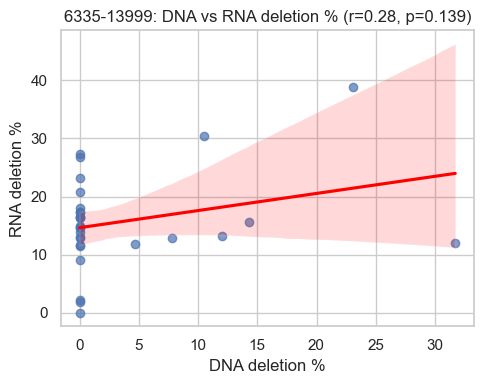

7816-14807 r = -0.106 p = 0.5845


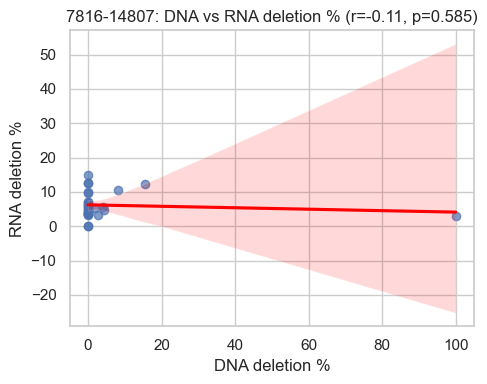

8471-13449 r = 0.142 p = 0.4639


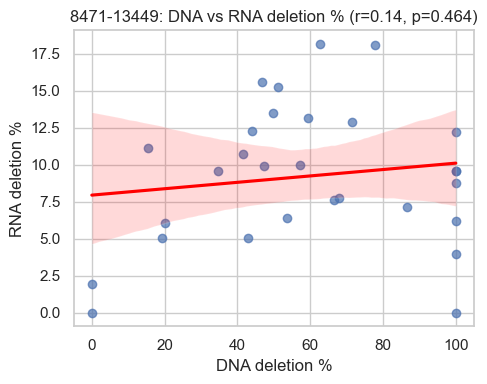

In [8]:
for col in del_cols:
    x = merged[col + '_pct_dna']
    y = merged[col + '_pct_rna']

    # Drop pairs with NaN or inf
    tmp = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()

    if len(tmp) < 2:
        print(col, "not enough valid points after removing NaNs/inf")
        continue

    r, p = pearsonr(tmp['x'], tmp['y'])
    print(col, "r =", round(r, 3), "p =", round(p, 4))

    plt.figure(figsize=(5, 4))
    sns.regplot(x=tmp['x'], y=tmp['y'],
                scatter_kws={'alpha': 0.7},
                line_kws={'color': 'red'})
    plt.xlabel("DNA deletion %")
    plt.ylabel("RNA deletion %")
    plt.title(f"{col}: DNA vs RNA deletion % (r={r:.2f}, p={p:.3g})")
    plt.tight_layout()
    plt.show()


In this 30‑sample UCI cohort, DNA‑ and RNA‑derived deletion percentages for the three recurrent deletions (6335–13999, 7816–14807, 8471–13449) show weak correlations (|r| ≤ 0.28, all p > 0.1). These results suggest that, at the individual‑deletion level and in this small sample, DNA–RNA concordance is limited, even though these deletions are highly prevalent. Larger cohorts and aggregate metrics (e.g., cumulative Top 30 burden) may show stronger concordance, as described by Omidsalar et al. (2024, Communications Biology).

In [18]:
import os
os.makedirs("figures", exist_ok=True)


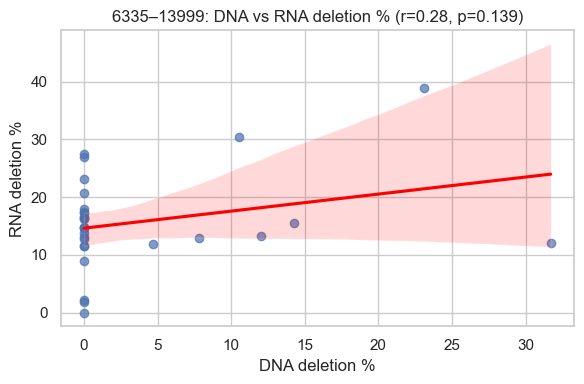

In [19]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

dna_col = "6335-13999_pct_dna"
rna_col = "6335-13999_pct_rna"

x = merged[dna_col]
y = merged[rna_col]

mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

r, p = pearsonr(x, y)

plt.figure(figsize=(6, 4))
sns.regplot(x=x, y=y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
plt.xlabel("DNA deletion %")
plt.ylabel("RNA deletion %")
plt.title(f"6335–13999: DNA vs RNA deletion % (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.savefig("figures/6335-13999_dna_rna_scatter.png", dpi=300)
plt.show()


In [20]:
plt.tight_layout()
plt.savefig("figures/6335-13999_dna_rna_scatter.png", dpi=300)
plt.show()


<Figure size 640x480 with 0 Axes>

In [21]:
dna_col = "6335-13999_pct_dna"
rna_col = "6335-13999_pct_rna"

print(merged[[dna_col, rna_col]].head())
print(merged[[dna_col, rna_col]].isna().sum())
print(merged[[dna_col, rna_col]].describe())


   6335-13999_pct_dna  6335-13999_pct_rna
0            0.000000           20.762712
1           31.707317           12.057272
2            0.000000            2.250352
3            0.000000           27.397260
4            0.000000           16.455696
6335-13999_pct_dna    1
6335-13999_pct_rna    0
dtype: int64
       6335-13999_pct_dna  6335-13999_pct_rna
count           29.000000           30.000000
mean             3.589888           15.616468
std              7.806037            8.047641
min              0.000000            0.000000
25%              0.000000           12.247628
50%              0.000000           14.670014
75%              0.000000           17.341821
max             31.707317           38.888889


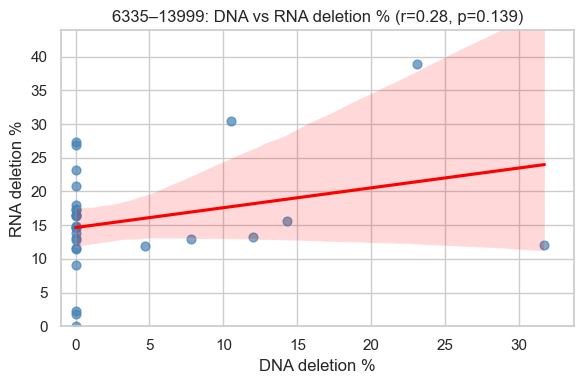

In [22]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

dna_col = "6335-13999_pct_dna"
rna_col = "6335-13999_pct_rna"

x = merged[dna_col]
y = merged[rna_col]

mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

r, p = pearsonr(x, y)

plt.figure(figsize=(6, 4))

sns.regplot(
    x=x,
    y=y,
    scatter_kws={'alpha': 0.7, 's': 40, 'color': 'steelblue'},
    line_kws={'color': 'red'}
)

plt.xlim(-1, x.max() + 2)   # small padding so points at 0 are visible
plt.ylim(0, y.max() + 5)

plt.xlabel("DNA deletion %")
plt.ylabel("RNA deletion %")
plt.title(f"6335–13999: DNA vs RNA deletion % (r={r:.2f}, p={p:.3g})")
plt.tight_layout()
plt.savefig("figures/6335-13999_dna_rna_scatter.png", dpi=300)
plt.show()
